# **CNN con PyTorch**

---

## **Creando nuestro propio Clasificador de Imágenes**

En este lab aprenderás:

* [Pytorch](https://pytorch.org/)
* [Torchvision](https://pytorch.org/vision/stable/index.html)
* Descargar un dataset, prepararlo, entrenarlo, realizar finetuning y guardarlo.

### **1. Cargar el dataset**

**Tenemos 2 formas:**

**1)** Cargar el dataset arrastrando el .zip hacia el notebook.

In [1]:
#!unzip "labeled-chest-xray-images.zip"

**2)** Guardar el .zip en Google Drive y luego darle permisos al notebook para que pueda accederlo.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

### **2. Preparación de la data**

#### **2.1 Instalamos las dependencias**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn


import torchvision
from torchvision import datasets, models, transforms


import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from pathlib import Path

#### **2.2 Tips de implementación**

In [4]:
# Configuración de GPU
cudnn.benchmark = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda:0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


#### **2.3 Data Augmentation**

In [5]:
# Data Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

#### **2.4 Dataset, Dataloader y más data**

In [6]:
# Ruta local del dataset
data_dir = Path("./chest_xray")
print("Dataset:", data_dir.resolve())
# Dataset y DataLoader
image_datasets = {
    x: datasets.ImageFolder(
        data_dir / x,
        data_transforms[x]
    )
    for x in ['train', 'val']
}

Dataset: C:\Users\Usuario\Desktop\IA_Siemens\clase6\parte_a\chest_xray


In [7]:
dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x],
        batch_size=4,
        shuffle=True,
        num_workers=0
    )
    for x in ['train', 'val']
}


dataset_sizes = {
    x: len(image_datasets[x])
    for x in ['train', 'val']
}


class_names = image_datasets['train'].classes
# Verificación
print("Clases:", class_names)


print("\nTamaño de los datasets:")
for x in ['train', 'val']:
    print(f"{x}: {dataset_sizes[x]} imágenes")


print("\nDispositivo:", device)


if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Clases: ['NORMAL', 'PNEUMONIA']

Tamaño de los datasets:
train: 5232 imágenes
val: 624 imágenes

Dispositivo: cuda:0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 7.96 GB


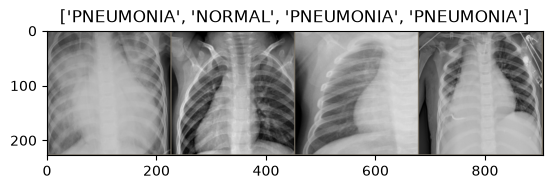

In [8]:
def imshow(inp, title=None):
    """Imshow para tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # Pausarlo un poco para que se actualicen los plots


# Obtener un batch de datos de entrenamiento
inputs, classes = next(iter(dataloaders['train']))

# Crear una grilla con las imágenes
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

***Evaluar las class_names***

In [9]:
print(class_names)

['NORMAL', 'PNEUMONIA']


### **3. Finetuning de la convnet**

#### **3.1 Definir capa tras capa de nuestra CNN**

Para este caso es una estructura estrictamente secuencial.

##### **CNN 1**

In [10]:
layers = [
    # Bloque conv → ReLU → pool
    nn.Conv2d(3, 4, kernel_size=3, padding=1),    # De 3 canales (RGB) a 4 mapas de características
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                           # Pooling reduce a la mitad la resolución

    # Aplanar y FCs (Capas fully-connected)
    nn.Flatten(),
    nn.Linear(4 * 112 * 112, 2)                   # Asume entrada 224×224 → tras pooling 112×112
]

#### **3.2 Montar el Sequential**

In [11]:
model_ft = nn.Sequential(*layers)

model_ft = model_ft.to(device)

### **4. Entrenamiento**

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Cada epoch tiene una fase de entrenamiento y validación.
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Fase entrenamiento
            else:
                model.eval()   # Fase validación

            running_loss = 0.0
            running_corrects = 0

            # Iterar sobre la data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history solo si es la fase de entrenamiento
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize solo si es la fase de entrenamiento
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy el modelo
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # Cargar el best model weights
    model.load_state_dict(best_model_wts)
    return model

In [13]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

#### **Definir Función de Loss y Optimizador**

In [14]:
criterion = nn.CrossEntropyLoss()

# Observe que todos los parámetros están siendo optimizados
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decae LR por un factor de 0.1 cada 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [15]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=5)

Epoch 0/4
----------
train Loss: 0.6357 Acc: 0.7412
val Loss: 0.5764 Acc: 0.6891

Epoch 1/4
----------
train Loss: 0.5470 Acc: 0.7555
val Loss: 0.5985 Acc: 0.6859

Epoch 2/4
----------
train Loss: 0.5455 Acc: 0.7596
val Loss: 0.5916 Acc: 0.6827

Epoch 3/4
----------
train Loss: 0.5265 Acc: 0.7726
val Loss: 0.6305 Acc: 0.6458

Epoch 4/4
----------
train Loss: 0.5132 Acc: 0.7724
val Loss: 0.6121 Acc: 0.6827

Training complete in 6m 24s
Best val Acc: 0.689103


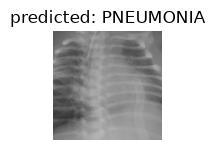

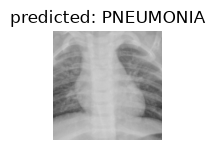

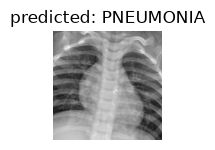

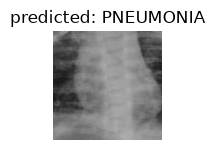

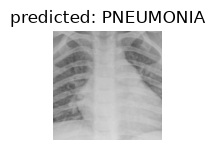

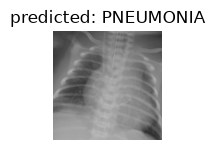

In [16]:
visualize_model(model_ft)

### **5. Guardar el modelo**

In [17]:
torch.save(model_ft, "model.pth")

### **6. Hacer Predicciones en Producción**

In [18]:
import torch
from torchvision import transforms
from PIL import Image

Cargar el modelo una vez (al inicio de la aplicación)

In [19]:
# Determinar el dispositivo
mi_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar el modelo en el dispositivo
mi_modelo = torch.load("model.pth", map_location=mi_device, weights_only=False)
mi_modelo.eval()
mi_modelo.to(mi_device)

Sequential(
  (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=50176, out_features=2, bias=True)
)

Función para predicción / inferencia

In [20]:
def predict_image(image_path, model, class_names, device):
    """
    Predice la clase de una imagen usando un modelo entrenado.

    Args:
        image_path (str): Ruta de la imagen.
        model (torch.nn.Module): Modelo ya cargado y configurado para inferencia.
        class_names (list): Lista de nombres de clases.
        device (torch.device): Dispositivo donde está el modelo.

    Returns:
        str: Clase predicha.
    """
    # Preprocesamiento de la imagen
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Cargar y preprocesar la imagen
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # Añadir dimensión batch y mover al dispositivo

    # Realizar predicción
    with torch.no_grad():
        outputs = model(image_tensor)
        _, preds = torch.max(outputs, 1)

    # Retornar la clase predicha
    return class_names[preds[0].item()]


Ejemplos de uso

In [21]:
class_names = ['NORMAL', 'PNEUMONIA']

In [22]:
path_image = "./chest_xray/val/NORMAL/NORMAL-2870844-0001.jpeg"

predicted_class = predict_image(
    path_image,
    mi_modelo,
    class_names,
    mi_device
)

print(f"La clase predicha es: {predicted_class}")

La clase predicha es: PNEUMONIA


In [23]:
path_image = "./chest_xray/val/PNEUMONIA/BACTERIA-3060399-0001.jpeg"

predicted_class = predict_image(
    path_image,
    mi_modelo,
    class_names,
    mi_device
)

print(f"La clase predicha es: {predicted_class}")

La clase predicha es: PNEUMONIA


### **7. Conclusiones**

- Aprender sobre los distintos objetos y métodos que nos ofrece Pytorch / Torchvision.

- Realizar el proceso completo de clasificación de imágenes con Pytorch.

- Aprender tips sobre implementación con el uso de la GPU.

<br>
<br>
<br>